<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.

Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.

In [1]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

  
Your models understand only numbers and shapes. 

In [ ]:
def Performance(model, X_test, y_test, name="Model"): 

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)  # gets the loss and accuracty of the model using the evaluate method of the model.

    # Print the results
    print(name + " performance:") 
    print("Optimization: " + str(round(loss, 5))) # prints the optimization (loss) rounded to 5 decimal places
    print("Accuracy: " + str(round(accuracy * 100, 5)) + "%")  # prints the accuracy as a percentage rounded to 5 decimal places, multiplying by 100 to convert from a decimal to a percentage
 
    return loss, accuracy # returns the loss and accuracy values as a tuple

Simple function assesses the ferformance of a trained model by calculating its loss and accuracy. This function is compatible for only classification models.

In [3]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)

print(scalar.shape, vector.shape, matrix.shape, tensor.shape)

() (3,) (2, 2) (2, 2, 1)


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?
### It is Rank 4 (batch, height, width, channels) shape is (32, 64, 64, 3) ###

In [4]:
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB 
print(img_batch.shape, img_batch.ndim) # (32, 64, 64, 3), rank=4

(32, 64, 64, 3) 4


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.

In [5]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats

A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.

In [6]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

: picks all rows. 
-1 selects the last column. last_col has shape (2,).

<b>Reshaping:</b>

expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).<br>
squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).

In [7]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, * operate per position. This is different from matrix multiplication (tf.matmul).

Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks. 

In [8]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

In [9]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
      "sum:", tf.reduce_sum(E).numpy())


min: 0 max: 97 mean: 45.9 sum: 459


<b>Extra example  of why should we change int to float:</b>

In [10]:

M = tf.constant([[1., 2.], [3., 4.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[2. 3.]
[1.5 3.5]


In [11]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)

Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]

In [12]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.

In [13]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


In [14]:
def check_optimization_vs_accuracy(model, X_train, y_train, X_test, y_test, epochs=5):
    
    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, verbose=1)
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print("Model evaluation:")
    print("Loss (optimization result):", loss)
    print("Accuracy:", accuracy)
    
    return history, loss, accuracy


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.

We use Matplotlib for visualization. 

In [15]:
#import tensorflow as tf
#import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20., -18., ..., 20.]
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">

Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).

In [17]:
# Train/test split (simple)
X_train, y_train = X[:22], y[:22] #changed the split to have more training samples for better learning
X_test, y_test = X[17:], y[17:] #changed the split to have more test samples for better evaluation

Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines. 

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models. 

API in this case means a set of classes and methods you call to build neural networks.

In [18]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)), # input layer for single feature
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop. 
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.

In [19]:
# 2) COMPILE
model.compile(
    loss="mae", #mean absolute error loss for regression
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.04), #changed learning rate to 0.04 for faster convergence after testing other different learning rates.
    metrics=["mae"] #mean absolute error metric to monitor during training
)

model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting. 
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras. 

In [20]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=250, verbose=1) #increased epochs to 250 for better convergence (of course after trying many other numbers of epochs)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 15.8667 - mae: 15.8667
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 12.6180 - mae: 12.6180
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 10.5372 - mae: 10.5372
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.9371 - mae: 9.9371
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.8971 - mae: 9.8971
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 9.8571 - mae: 9.8571
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 9.8171 - mae: 9.8171
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.7771 - mae: 9.7771
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.7371 - mae: 9.7371
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 9.6971 - mae: 9.6971
Epoch 11/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 9.6571 - mae: 9.6571
Epoch 12/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.6171 - mae: 9.6171
Epoch 13/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br> 
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.

In [21]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0) #evaluate on test set which means it will compute the mean absolute error on the test set without printing the progress (verbose=0)
print("Test MAE:", mae) #mean absolute error on test set 


Test MAE: 0.11247396469116211


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


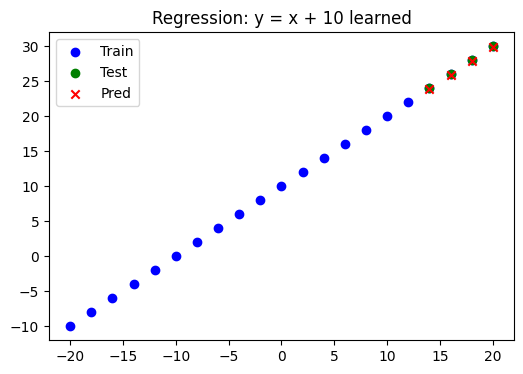

In [22]:
# Predict and visualize
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4)) #set figure size bigger numbers = bigger figure
plt.scatter(X_train, y_train, c='b', label='Train') #training data will be in blue labelled 'Train'
plt.scatter(X_test,  y_test,  c='g', label='Test') #test data will be in green labelled 'Test'
plt.scatter(X_test,  y_pred,  c='r', marker='x', label='Pred') #same like before but this time changed the marker to 'x' for better visibility
plt.legend(); plt.title("Regression: y = x + 10 learned") #title of the plot
plt.show()

HOMEWORK: Fix the regression model

<h1>Classification</h1>

Test accuracy: 1.000
Model performance:
Optimization: 0.0139
Accuracy: 100.0%


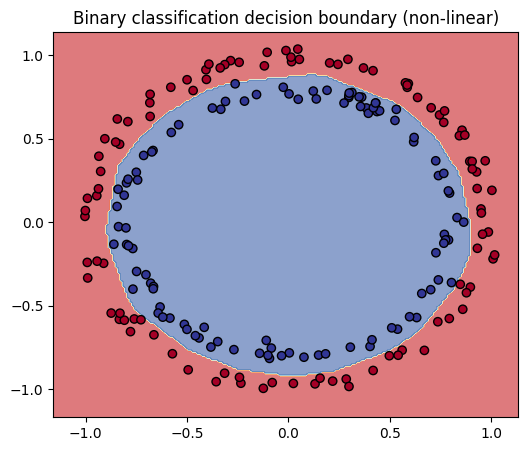

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split #imports

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42) #1000 samples, some noise, for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42) # test size 0.2 means 20% test, 80% train and random state for reproducibility.

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)), # input layer for 2D features
    tf.keras.layers.Dense(16, activation="relu"), # first hidden layer with 16 neurons and ReLU activation for non-linearity
    tf.keras.layers.Dense(16, activation="relu"),   # second hidden layer with 16 neurons and ReLU activation for non-linearity
    tf.keras.layers.Dense(1, activation="sigmoid") # output layer with sigmoid activation for binary classification (yes or no output)
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy", # binarry crossentropy is for binary classification problems becuase it measures the distance between the predicted probabilities and the true binary labels, 
                                # making it suitable for optimizing models that output probabilities for two classes.
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), #Adam is chosen for its efficiency and good performance on a wide range of problems, and the learning rate is set to 0.01
    metrics=["accuracy"] #accuracy metric to monitor during training
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0) #25 epoch means it will go through the entire training dataset 25 times during training.

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0) #evaluate on test set
print(f"Test accuracy: {acc:.3f}") # not necessary since the funtion below will evaluate and print anyways...


Performance(model, X_test, y_test, name="Model")


# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),  # meshgrid creates a grid of points over the feature space for visualization, 
                                                                            #0 , -0.1 and 0 means a small padding around the min and max values of the features to ensure the decision boundary is fully visible 
                                                                            #200 means the resolution of the grid (more points = smoother boundary but slower prediction)
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))  #same as before but for the second feature (y-axis)
grid = np.c_[xx.ravel(), yy.ravel()] # np.c is used to concatenate the raveled (flattened) xx and yy arrays column-wise to create a grid of points for prediction.
probs = model.predict(grid, verbose=0).reshape(xx.shape) #predict probabilities for each point in the grid and reshape to match the shape of xx for contour plotting

plt.figure(figsize=(6,5)) #fig size again
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6) #contourf is used to plot the decision boundary
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k') #scatter plot of the test data, rdylbu is a colormap which stands red yellow blue and edgecolor k means black edges. why black is k? who knows
plt.title("Binary classification decision boundary (non-linear)") 
plt.show()




Test accuracy: 0.8837000131607056
Model performance:
Optimization: 0.33781
Accuracy: 88.37%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


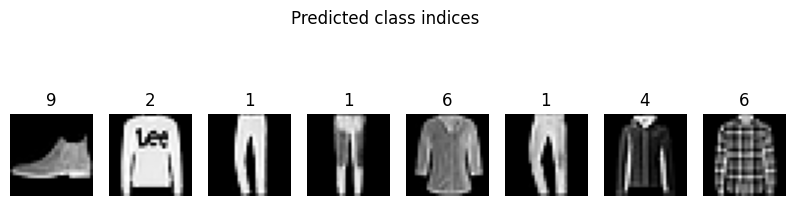

In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data() #downloadds and loads the dataset which is a collection of grayscale images of cloth items

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0 # it converts the pixel values from integers to  floats and scales them to the range [0, 1] by dividing by 255
x_test  = x_test.astype("float32")/255.0 

# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([ #the model is a sequential stack of layers
    tf.keras.layers.Input(shape=(28, 28)), # input layer for 28x28 pixel images (since they are grayscale, no color channels needed such as "RGB")
    tf.keras.layers.Flatten(), #flatten layer to convert the 2d images into 1d vectores (i found out that this was the biggest reason why i was getting soo high numbers of parameters.)
    tf.keras.layers.Dense(128, activation="relu"), #hidden layer with 128 neurons and ReLU activation for non-linearity, relu means rectified linear unit.
    tf.keras.layers.Dense(10, activation="softmax") #output layer wuth 10 neurons and softmax activation for multi-class classification (10 classes of clothing items)
])

# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot and since its multiclass, this loss function is well suited
    optimizer="adam", #Adam is chosen for its efficiency and good performance on a wide range of problems
    metrics=["accuracy"] 
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0) #validation split adds a validation set from the training data to monitor performance during training
                                                                                    #0.1 neabs 10% of the training data will be used for validating
                                                                                    # u can change berbose to 1 if u want to see the training progress

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0) #evaluate on test set which means it will compute the mean absolute error on the test set without printing the progress since verbose=0
print("Test accuracy:", acc) # not necessary since the funtion below will evaluate and print anyways...

Performance(model, x_test, y_test, name="Model") #calls the function defined earlier on notebook to evaluate the model and print the performance metrtics

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1) # :8 means we are taking the first 8 images from the test set to predict and visualize
plt.figure(figsize=(10,3)) # u know what figure size again
for i in range(8):
    plt.subplot(1,8,i+1) #subplot means we are creating a grid of 1 row and 8 columns to display the 8 test images and their predictions
    plt.imshow(x_test[i], cmap='gray') #imshow means it will display the gray scale image of the test sample at index i
    plt.title(int(preds[i])) #predicted class index as title (0-9 corresponding to the clothing item classes)
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data() #same as before, load the fashion mnist dataset which is a collection of grayscale images of cloth items and their corresponding labels (0-9)
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9]) #np isin creates a boolean mask where True indicates the positions of elements in y_train that are either 7 or 9, this is only for binary classification between these two classes
test_mask  = np.isin(y_test,  [7, 9]) # same but for the test set

x_train = x_train[train_mask][..., None]/255.0 #keep only the images that belongs to class 7 or 9
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0
x_test  = x_test[test_mask][..., None]/255.0 #keep only iamges that belonfs to class 7 or 9
y_test  = (y_test[test_mask] == 9).astype(np.float32) # same as before 1 if class 9 or 0 if not which means it will be class 7 since we are doing only images that belong to 7 or 9

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)), # input layer for 28x28 pixel images with 1 channel
    tf.keras.layers.Conv2D(16, 3, activation="relu"), # first convolutional layer with 16 filters, kernel size of 3x3, and ReLU activation for non-linearity
    tf.keras.layers.MaxPool2D(), #maxpooling layer will reduce the spatial dimensions of the map by taking the max value in each 2x2 window(helps on reducing parameters)
    tf.keras.layers.Conv2D(32, 3, activation="relu"), # second convolutional layer with 32 filters, kernel size of 3x3, and ReLU activation for non-linearity
    tf.keras.layers.MaxPool2D(), #same as before but for the second convolutional layer
    tf.keras.layers.Flatten(), #we talked about flatten layer before, 2d to 1d...
    tf.keras.layers.Dense(64, activation="relu"), #hidden layer with 64 neurons and ReLU activation for non-linearity
    tf.keras.layers.Dense(1, activation="sigmoid") # output layer with sigmoid activation for binary classification (yes or no))
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0) #same as previous training

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

Performance(model, x_test, y_test, name="Model") #calls the function defined earlier on notebook to evaluate the model and print the performance metrtics



Test accuracy: 0.9664999842643738
Model performance:
Optimization: 0.09332
Accuracy: 96.65%


(0.09332331269979477, 0.9664999842643738)

In [26]:

import tensorflow as tf
from keras import layers, models

# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data() #cifar10 is a collection of 60000 32x32 color images in 10 classes

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten() # #training data will be only the images that belong to class 0,1,2 and flatten will convert the 2d array of labels into a 1d array for easier indexing
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    layers.MaxPooling2D(), #max pooling to reduce spatial dimensions and parameters

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"), #hidden layer with 64 neurons and ReLU activation for non-linearity
    layers.Dense(3, activation="softmax") #output layer with 3 neurons (for 3 classes) and softmax activation for multi-class classification
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64, # batch size means the number of samples that will used in the forward and backward pass during the training process.
    validation_split=0.1, # test size 0.1 means 10% of the training data will be used for validating
    verbose=1 #will show the training progress
)

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc) # not necessary since the funtion below will evaluate and print anyways...

Performance(model, x_test, y_test, name="Model") #calls the function defined earlier on notebook to evaluate the model and print the performance metrtics




d:\LAB\2026\Spring\Implementing_IoT_Pipeline\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/5


d:\LAB\2026\Spring\Implementing_IoT_Pipeline\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7176 - loss: 0.6563 - val_accuracy: 0.8387 - val_loss: 0.4220
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8468 - loss: 0.3875 - val_accuracy: 0.8693 - val_loss: 0.3439
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8763 - loss: 0.3171 - val_accuracy: 0.8833 - val_loss: 0.3147
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8913 - loss: 0.2814 - val_accuracy: 0.9007 - val_loss: 0.2698
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9059 - loss: 0.2414 - val_accuracy: 0.9207 - val_loss: 0.2315
Test accuracy (tiny CNN): 0.9066666960716248
Model performance:
Optimization: 0.24683
Accuracy: 90.66667%


(0.2468307763338089, 0.9066666960716248)

Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


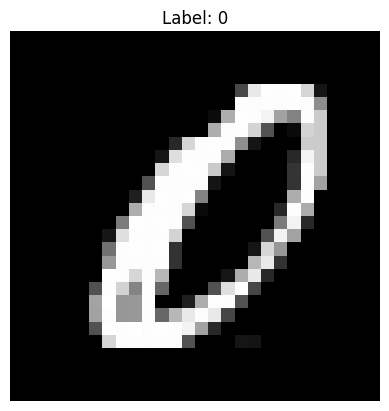

d:\LAB\2026\Spring\Implementing_IoT_Pipeline\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9078 - loss: 0.3319 - val_accuracy: 0.9464 - val_loss: 0.1859
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9568 - loss: 0.1520 - val_accuracy: 0.9603 - val_loss: 0.1365
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9696 - loss: 0.1067 - val_accuracy: 0.9679 - val_loss: 0.1137
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0802 - val_accuracy: 0.9671 - val_loss: 0.1091
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9821 - loss: 0.0624 - val_accuracy: 0.9733 - val_loss: 0.0944


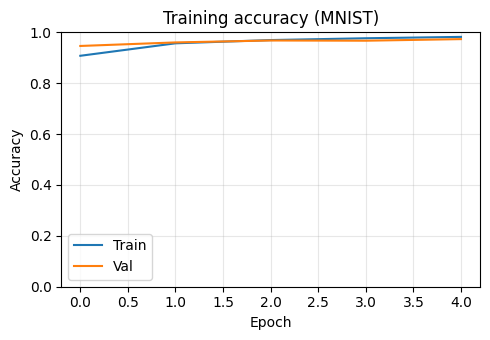

Test accuracy: 0.972
Model performance:
Optimization: 0.08851
Accuracy: 97.16%
You must install pydot (`pip install pydot`) for `plot_model` to work.


'model_mnist.png'

In [27]:
import keras
from keras.datasets import mnist
from keras.utils import plot_model

# --- Load MNIST ---
(x_train, y_train), (x_test, y_test) = mnist.load_data() #mnist is a dataset of 70000 28x28 grayscale images of handwritten digits (0-9) and their corresponding labels
x_train = x_train.astype("float32") / 255.0 #float32 is used to conver the pixel values from integers to floats
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# --- Show ONE random image ---
def show_one_example(X, y):
    i = np.random.randint(len(X)) #randomly selects and index from the dataset
    plt.imshow(X[i], cmap="gray", vmin=0, vmax=1) #show the image of the selected index in graysclae
    plt.title(f"Label: {y[i]}") #label
    plt.axis("off") #no axes
    plt.show()

show_one_example(x_train, y_train) 

# --- Model ---
model = keras.Sequential([ #the model is a sequential stack of layers
    layers.Flatten(input_shape=(28, 28)), # input layer that flattens the 28x28 pixel images into a 1D vector of 784 features
    layers.Dense(128, activation="relu"), #hidden layer with 128 neurons and ReLU activation for non-linearity
    layers.Dense(10, activation="softmax") #output layer with 10 neurons (for 10 classes) and softmax activation for multi-class classification
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", # labels are ints, not one-hot and since its multiclass, this loss function is well suited
    metrics=["accuracy"]
)

model.summary()

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2, # validation is split is 0.2 means 20% of the training data will be used for validating
    verbose=1
)

# --- Accuracy plot ---
plt.figure(figsize=(5, 3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (MNIST)")
plt.tight_layout()
plt.show()

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}") # not necessary since the funtion below will evaluate and print anyways...

Performance(model, x_test, y_test, name="Model") #calls the function defined earlier on notebook to evaluate the model and print the performance metrtics


# --- Model diagram ---
plot_model(
    model,
    to_file="model_mnist.png"
)

display("model_mnist.png") # having an image here was giving some error so i jsut removed it :)

Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


Model: "parallel_mlp_mnist"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 28, 28)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 64)        │     50,240 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 64)        │     50,240 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 128)       │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10)        │      1,290 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9090 - loss: 0.3278 - val_accuracy: 0.9501 - val_loss: 0.1839
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9558 - loss: 0.1509 - val_accuracy: 0.9613 - val_loss: 0.1304
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9689 - loss: 0.1069 - val_accuracy: 0.9670 - val_loss: 0.1109
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9761 - loss: 0.0808 - val_accuracy: 0.9703 - val_loss: 0.1010
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9809 - loss: 0.0644 - val_accuracy: 0.9731 - val_loss: 0.0917


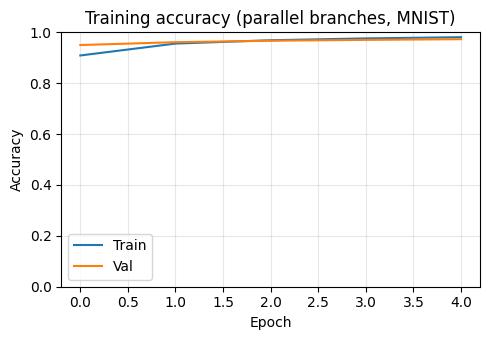

Test accuracy: 0.975
Model performance:
Optimization: 0.08448
Accuracy: 97.48%
You must install pydot (`pip install pydot`) for `plot_model` to work.


'parallel_mlp.png'

In [28]:

# --- Load & prep MNIST ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)   # (60000, 28, 28), (60000,)
print("Test: ", x_test.shape,  y_test.shape)    # (10000, 28, 28), (10000,)

# --- Parallel-branches MLP (Functional API) ---
inputs = keras.Input(shape=(28, 28), name="input")
x = layers.Flatten(name="flatten")(inputs)                # (None, 784)

# Branch A
branch_a = layers.Dense(64, activation="relu", name="branchA_dense")(x)

# Branch B
branch_b = layers.Dense(64, activation="relu", name="branchB_dense")(x)

# Merge
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# Output: 10 classes for MNIST digits 0..9
outputs = layers.Dense(10, activation="softmax", name="output")(merged)

model = keras.Model(inputs, outputs, name="parallel_mlp_mnist")

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# --- Plot accuracy ---
plt.figure(figsize=(5, 3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (parallel branches, MNIST)")
plt.tight_layout()
plt.show()

# --- Evaluate on test set ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}") # not necessary since the funtion below will evaluate and print anyways...

Performance(model, x_test, y_test, name="Model") #calls the function defined earlier on notebook to evaluate the model and print the performance metrtics



# --- Model diagram ---
plot_model(
    model,
    to_file="parallel_mlp.png"
)

display("parallel_mlp.png")

In [29]:
import os

# --- Load & prep MNIST ---
(x_train, y_train), (x_test, y_test) = mnist.load_data() 
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)   # (60000, 28, 28), (60000,)
print("Test: ", x_test.shape,  y_test.shape)    # (10000, 28, 28), (10000,)

# --- MLP model ---
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # flattens 28x28 -> 784
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax") # 10 classes for digits 0..9
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}") # not necessary since the funtion below will evaluate and print anyways...

Performance(model, x_test, y_test, name="Model") #calls the function defined earlier on notebook to evaluate the model and print the performance metrtics


# --- Save to a .keras file ---
save_path = "uuniis_model.keras"
model.save(save_path)
print("Saved model to:", os.path.abspath(save_path)) #saves the trained model to chosen file path and prints the absolute path.

Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)
Epoch 1/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9221 - loss: 0.2793 - val_accuracy: 0.9541 - val_loss: 0.1585
Epoch 2/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9624 - loss: 0.1270 - val_accuracy: 0.9656 - val_loss: 0.1194
Epoch 3/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9747 - loss: 0.0868 - val_accuracy: 0.9721 - val_loss: 0.0975
Epoch 4/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9802 - loss: 0.0652 - val_accuracy: 0.9696 - val_loss: 0.0978
Epoch 5/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9847 - loss: 0.0489 - val_accuracy: 0.9751 - val_loss: 0.0891
Epoch 6/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9887 - loss: 0.0381 - val_accuracy: 0.9711 - val_loss: 0.0973
Test accuracy: 0.975
Model performance:
Optimization: 0.083
Accuracy: 97.46%
Saved model to: d:\LAB\2026\Spring\Implementing_IoT_Pipeline\Machine Learning\uuniis_

In [30]:
# --- Load & prep MNIST (same dataset as your training cell) ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_test = x_test.astype("float32") / 255.0  # test set is enough for evaluation

print("Test:", x_test.shape, y_test.shape)  # (10000, 28, 28), (10000,)

# --- Load the saved .keras model ---
loaded_model = keras.saving.load_model("uuniis_model.keras") 
loaded_model.summary()

# --- Evaluate the loaded model on MNIST test ---
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")

# --- Predict a few samples ---
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 10) for MNIST
preds = probs.argmax(axis=1)

print("Predictions:", preds.tolist())
print("True labels:", y_test[:5].tolist())

Test: (10000, 28, 28) (10000,)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

Loaded model - test accuracy: 0.975
Predictions: [7, 2, 1, 0, 4]
True labels: [7, 2, 1, 0, 4]
